Objective:

Utilize Python, Pandas, NumPy, and SciPy to conduct a thorough analysis of the “Airplane Crashes and Fatalities upto 2023” dataset. This challenge will encompass data cleaning, exploratory analysis, statistical testing, and visualization to draw meaningful insights.


Dataset:

Work with the “Airplane Crashes and Fatalities upto 2023” dataset, which provides comprehensive details about airplane crashes, including dates, locations, fatalities, and more. Access the dataset here.

Tasks:

1. Data Import and Cleaning:

    Import the dataset using Pandas.
    Clean and preprocess the data, addressing missing values and categorizing data as needed.
    Convert dates and other relevant fields to appropriate formats.

2. Exploratory Data Analysis:

    Use Pandas to explore basic statistics such as the number of crashes, fatalities, and survival rates.
    Analyze the frequency of crashes over time to identify any trends.

3. Statistical Analysis:

    Apply SciPy to analyze the distribution of fatalities and survival rates. Calculate key statistics like mean, median, and standard deviation.
    Conduct a hypothesis test (e.g., comparing the average number of fatalities in different decades or regions).

4. Visualization:

    Create charts and graphs using Matplotlib and Seaborn to visualize the findings from your exploratory data analysis and statistical tests.
    Examples might include time series plots of crashes over years, bar charts of crashes by region, and histograms of fatalities.

5. Insight and Report:

    Summarize your findings and provide insights into the patterns or anomalies discovered in the data.
    Prepare a well-structured report including all code, visualizations, and interpretations.


In [5]:
# 1. Data Import and Cleaning:

#     Import the dataset using Pandas.
#     Clean and preprocess the data, addressing missing values and categorizing data as needed.
#     Convert dates and other relevant fields to appropriate formats. -->
import pandas as pd
df = pd.read_csv('plane_data.csv', encoding='latin1')
df.head()

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [8]:
df.shape

(4998, 17)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   str    
 1   Time                   3486 non-null   str    
 2   Location               4994 non-null   str    
 3   Operator               4988 non-null   str    
 4   Flight #               1329 non-null   str    
 5   Route                  4221 non-null   str    
 6   AC Type                4983 non-null   str    
 7   Registration           4724 non-null   str    
 8   cn/ln                  4330 non-null   str    
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities Crew        4757 non-null   float64
 15  Ground         

In [16]:
# #Dealing with missing values:
# # Several columns have missing values. To deal with this, first we will create a copy of the dataframe with only the columns that are of interest to us. We will be analyzing the number of crashes, fatalities, and survival rates over time and by region. So the relevant columns are:
# Date, Location, Aboard, and Fatalities. (Number of crashes is number of rows.)
# The Date column is full (4998 non-null), so we can do analysis of number of crashes over time with all rows. Location has 4994 values, almost all. Aboard has 4980 values, almost all. Fatalities has 4990 values, almost all. So in our new dataset we can simply remove the rows without values for those columns.

df1 = df[['Date','Location', 'Aboard', 'Fatalities']].dropna()

#Next we can convert the Date column to correct date format.
df1['Date'] = pd.to_datetime(df1['Date'], format='%m/%d/%Y', errors='coerce')
# Create a survival rate column:
df1['Survival Rate'] = 1 - df1['Fatalities']/df1['Aboard']
df1.head(10)

,Date,Location,Aboard,Fatalities,Survival Rate
0,1908-09-17,"Fort Myer, Virginia",2.0,1.0,0.500000
1,1909-09-07,"Juvisy-sur-Orge, France",1.0,1.0,0.000000
2,1912-07-12,"Atlantic City, New Jersey",5.0,5.0,0.000000
3,1913-08-06,"Victoria, British Columbia, Canada",1.0,1.0,0.000000
4,1913-09-09,Over the North Sea,20.0,14.0,0.300000
5,1913-10-17,"Near Johannisthal, Germany",30.0,30.0,0.000000
6,1915-03-05,"Tienen, Belgium",41.0,21.0,0.487805
7,1915-09-03,"Off Cuxhaven, Germany",19.0,19.0,0.000000
8,1916-07-28,"Near Jambol, Bulgeria",20.0,20.0,0.000000
9,1916-09-24,"Billericay, England",22.0,22.0,0.000000


In [18]:
# 2. Exploratory Data Analysis:

#     Use Pandas to explore basic statistics such as the number of crashes, fatalities, and survival rates.

df1.describe()

,Date,Aboard,Fatalities,Survival Rate
count,4976,4976.000000,4976.000000,4971.000000
mean,1971-08-07 20:35:41.479099,31.217243,22.416399,0.181467
min,1908-09-17 00:00:00,0.000000,0.000000,0.000000
25%,1951-07-19 00:00:00,7.000000,4.000000,0.000000
50%,1970-12-31 00:00:00,16.000000,11.000000,0.000000
75%,1992-07-14 00:00:00,35.000000,25.000000,0.250000
max,2023-11-01 00:00:00,644.000000,583.000000,1.000000
std,NaN,45.546826,35.099804,0.311788


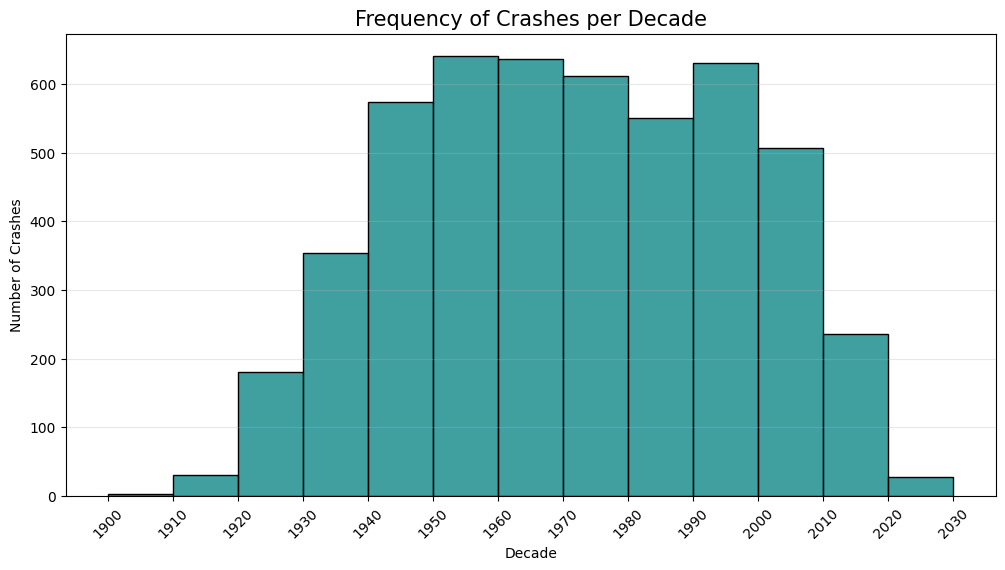

In [21]:
# Analyze the frequency of crashes over time to identify any trends.
# Create a histogram over the time parameter, with bins for decade.
# To do so we will first add a year parameter.
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df1['Year'] = df1['Date'].dt.year

# To define the decade bins:
# We round the minimum year down to the nearest 10 and the max up to the nearest 10
min_year = (df1['Year'].min() // 10) * 10
max_year = (df1['Year'].max() // 10 + 1) * 10
decade_bins = range(min_year, max_year + 10, 10)

plt.figure(figsize=(12, 6))
sns.histplot(df1['Year'], bins=decade_bins, color='teal', edgecolor='black')

# Formatting
plt.title('Frequency of Crashes per Decade', fontsize=15)
plt.xlabel('Decade')
plt.ylabel('Number of Crashes')
plt.xticks(decade_bins, rotation=45) # Set x-ticks to match decade starts
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
#Conclusion: The number of crashes has generally increased through 1940, stayed steady through 2000, and has been decreasing significantly since.

In [29]:
# 3. Statistical Analysis:

#     Apply SciPy to analyze the distribution of fatalities and survival rates. Calculate key statistics like mean, median, and standard deviation.
## There is no need to apply SciPy to analyze mean, median, and std. dev. All those statistics are already shown in df1.describe(), which we performed above.
#So we will just apply SciPy in short to show what the SciPy describe summary does.
from scipy import stats
stats.describe(df1['Fatalities'])

DescribeResult(nobs=np.int64(4976), minmax=(np.float64(0.0), np.float64(583.0)), mean=np.float64(22.416398713826368), variance=np.float64(1231.9962255004928), skewness=np.float64(4.600663594940144), kurtosis=np.float64(36.514177802513004))

In [36]:
#     Conduct a hypothesis test (e.g., comparing the average number of fatalities in different decades or regions).

## My hypothesis: The survival rate increased over time.
## To do so we can check if there is a correlation between year and survival rate.
## We can calculate the Pearson Correlation between Year and Survival Rate.

correlation = df1['Year'].corr(df1['Survival Rate'])
print(f"Pearson Correlation: {correlation:.4f}")

#from scipy.stats import pearsonr

#corr, _ = pearsonr(df1['Year'], df1['Survival Rate'])
#print(f'Pearson Correlation Coefficient: {corr:.2f}')


Pearson Correlation: 0.0604


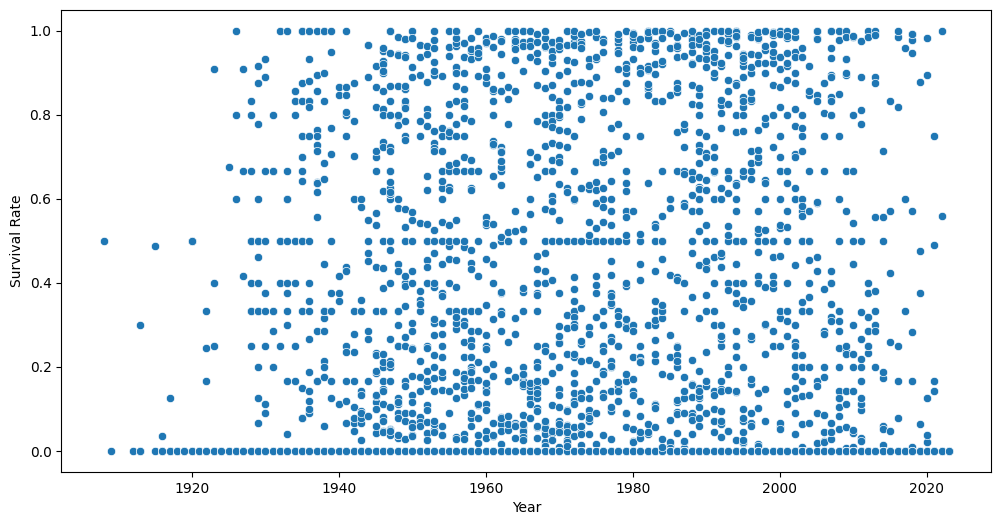

In [ ]:
#Conclusion: This seems to show a very limited correlation between year and survival rate.

# 4. Visualization:

#     Create charts and graphs using Matplotlib and Seaborn to visualize the findings from your exploratory data analysis and statistical tests.
#     Examples might include time series plots of crashes over years, bar charts of crashes by region, and histograms of fatalities.
# First I will create a scatterplot of Year vs. Survival Rate to further examine my hypothesis.
plt.figure(figsize=(12, 6))
sns.scatterplot(df1, x='Year', y='Survival Rate')
plt.show()


In [40]:
#Looking at the scatterplot supports the conclusion that there is no clear correlation between Year and Survival Rate.

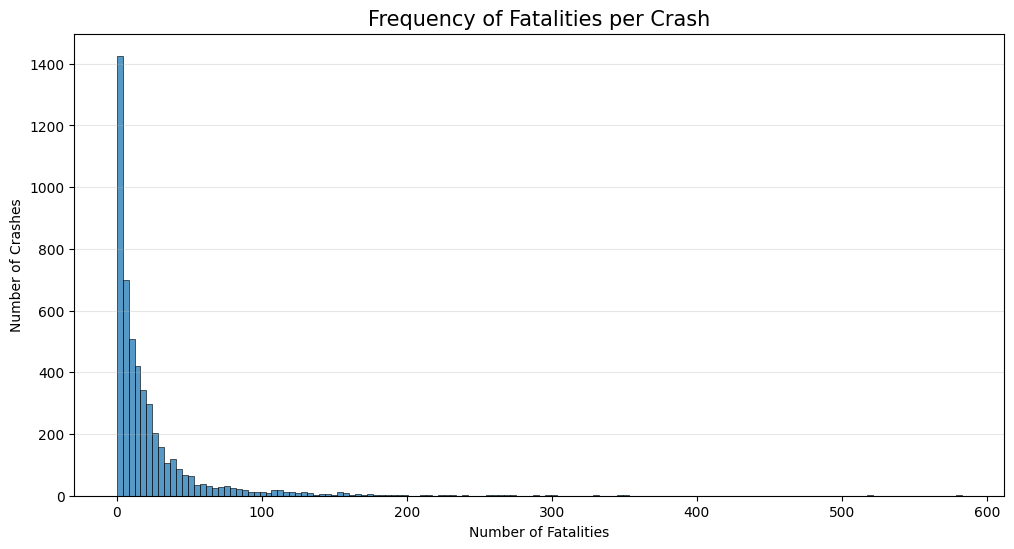

In [44]:
# Other charts: I've already made a plot of crashes over time. I don't see a practical way to divide the crashes by region because the location column is not encoded in a way that offers easy categorization by region. We can, though, make a histogram of fatalities:
plt.figure(figsize=(12, 6))
sns.histplot(df1['Fatalities'])

# Formatting
plt.title('Frequency of Fatalities per Crash', fontsize=15)
plt.xlabel('Number of Fatalities')
plt.ylabel('Number of Crashes')
plt.grid(axis='y', alpha=0.3)

plt.show()

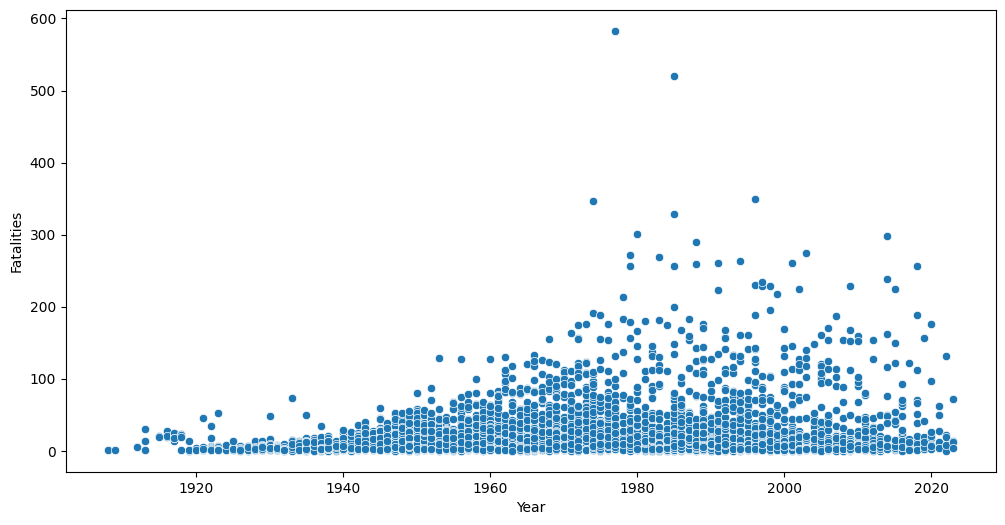

In [46]:
#We can also do a scatterplot of fatalities over time:
plt.figure(figsize=(12, 6))
sns.scatterplot(df1, x='Year', y='Fatalities')
plt.show()

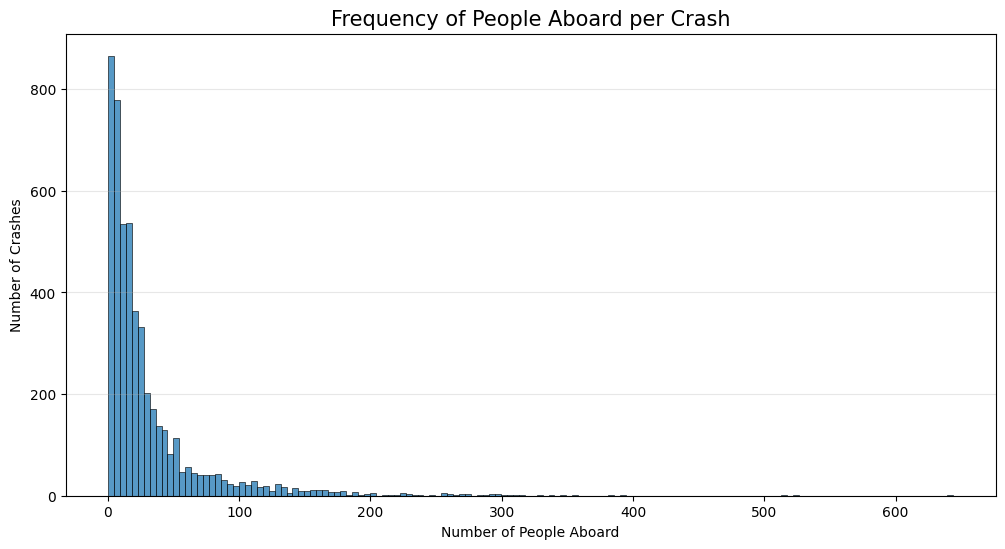

In [49]:
#We can see from this diagram that over time, the vast majority of crashes had between 0 and 100 fatalities, but starting around 1950 and even more so around 1970 there were also a significant number of crashes with many more fatalities (100 or more).
# What about number of people on board crashes?
#Here is a histogram.
plt.figure(figsize=(12, 6))
sns.histplot(df1['Aboard'])

# Formatting
plt.title('Frequency of People Aboard per Crash', fontsize=15)
plt.xlabel('Number of People Aboard')
plt.ylabel('Number of Crashes')
plt.grid(axis='y', alpha=0.3)

plt.show()

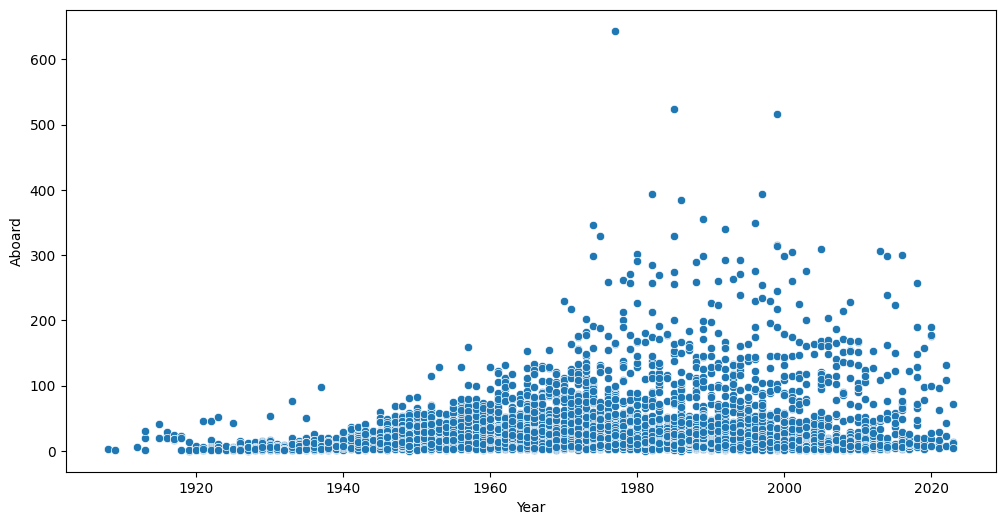

In [51]:
#We can see that the vast majority of crashes are of smaller planes with fewer than 50 people on board. Is this consistent over time? Let's look at a scatterplot.
#We can also do a scatterplot of fatalities over time:
plt.figure(figsize=(12, 6))
sns.scatterplot(df1, x='Year', y='Aboard')
plt.show()

In [ ]:
#We see here that the number of people aboard on crashes remained generally low over time though the number of crashes with more people aboard increased over time as well.

Conclusion: Insights and Interpretations
The number of crashes has generally increased from through 1940, stayed steady through 2000, and has been decreasing significantly since. The increase from 1908 to 1940 may be mainly due to an increase in the number of flights, while the decrease since 2000 seems more likely to be due to safety improvements.
There seems to be a very limited correlation between year and survival rate. This does not necessarily contradict our previous interpretation that there may have been safety improvements since 2000; it may be that safety improvements were in preventing crashes more than in increasing the survival rate for crashes.
Another interesting insight is that the vast majority of crashes were of flights with a small number of people on board, and thus a small number of fatalities, although the number of crashes of flights with many people on board and thus a larger number of fatalities increased somewhat over the years. We may posit based on this that smaller planes are more likely to crash than larger planes.
Additional insight could be gleaned by dividing the data into separate segments categorized by flight size (number of people aboard.)
